# Qdrant PoC - Ingest/Search Visualization
Run the cells top-to-bottom. You can override paths with env vars:
- `API_URL` (default: http://localhost:8001)
- `IMAGE_PATH` (default: /workspace/PoC/dogface_fastapi_poc/test_images/images.jpg)
- `DAYCARE_ID` (default: dc_001)


In [1]:
import os
from pathlib import Path
from typing import List, Dict, Any
import requests
from PIL import Image, ImageDraw, UnidentifiedImageError
import matplotlib.pyplot as plt

API_URL = os.environ.get('API_URL', 'http://localhost:8001')
IMAGE_PATH = os.environ.get('IMAGE_PATH', '/workspace/PoC/dogface_fastapi_poc/test_images/images.jpg')
DAYCARE_ID = os.environ.get('DAYCARE_ID', 'dc_001')

print('API_URL:', API_URL)
print('IMAGE_PATH:', IMAGE_PATH)


API_URL: http://localhost:8001
IMAGE_PATH: /workspace/PoC/dogface_fastapi_poc/test_images/images.jpg


In [2]:
def load_image(path: str) -> Image.Image | None:
    try:
        img = Image.open(path)
        img = img.convert('RGB')
        return img
    except UnidentifiedImageError:
        return None

def is_valid_image(path: str) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def collect_images(dirs, exts=None, limit=12):
    exts = exts or {'.jpg', '.jpeg', '.png'}
    paths = []
    for d in dirs:
        if not d.exists():
            continue
        for p in d.rglob('*'):
            if p.suffix.lower() in exts:
                paths.append(p)
    return paths[:limit]

def ingest_image(path: str, include_embedding: bool = False) -> Dict[str, Any]:
    url = f'{API_URL}/v1/ingest?include_embedding={str(include_embedding).lower()}'
    with open(path, 'rb') as f:
        files = {'file': f}
        data = {'daycare_id': DAYCARE_ID}
        resp = requests.post(url, files=files, data=data, timeout=60)
    resp.raise_for_status()
    return resp.json()

def draw_boxes(img: Image.Image, instances: List[Dict[str, Any]]) -> Image.Image:
    out = img.copy()
    draw = ImageDraw.Draw(out)
    w, h = out.size
    for inst in instances:
        bb = inst.get('bbox') or {}
        x1 = int(bb.get('x1', 0) * w)
        y1 = int(bb.get('y1', 0) * h)
        x2 = int(bb.get('x2', 0) * w)
        y2 = int(bb.get('y2', 0) * h)
        draw.rectangle([x1, y1, x2, y2], outline='red', width=2)
        inst_id = inst.get('instance_id', '')
        if inst_id:
            draw.text((x1 + 3, y1 + 3), inst_id, fill='yellow')
    return out

def crop_instances(img: Image.Image, instances: List[Dict[str, Any]]) -> List[Image.Image]:
    w, h = img.size
    crops = []
    for inst in instances:
        bb = inst.get('bbox') or {}
        x1 = int(bb.get('x1', 0) * w)
        y1 = int(bb.get('y1', 0) * h)
        x2 = int(bb.get('x2', 0) * w)
        y2 = int(bb.get('y2', 0) * h)
        if x2 > x1 and y2 > y1:
            crops.append(img.crop((x1, y1, x2, y2)))
    return crops

def show_grid(images: List[Image.Image], cols: int = 4, title: str = ''):
    if not images:
        print('No crops to show')
        return
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]
    for ax, im in zip(axes, images):
        ax.imshow(im)
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.show()


## Scenario A: Browse sample images from existing datasets
We sample images from the petface notebooks datasets and show a grid.


sample count: 11
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/sample_5m_ago.png
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/Biggles_1.jpg
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/2.png
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/Biggles_0.jpg
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/red_0.png


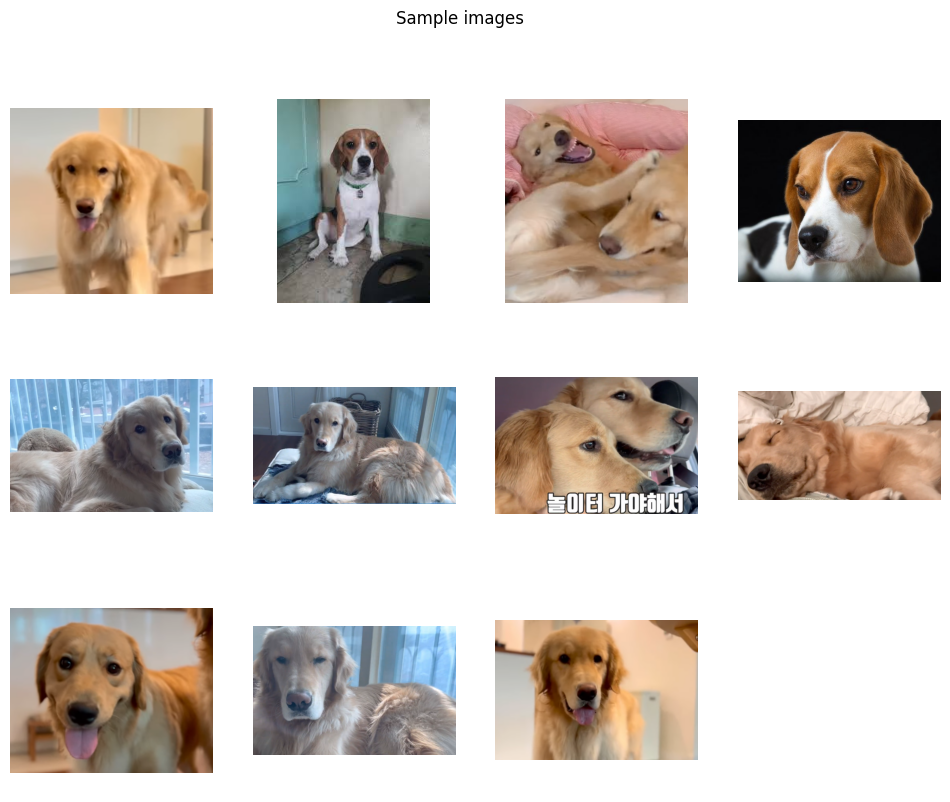

In [3]:
IMAGE_DIRS = [
    Path('/workspace/PoC/petface_yolov8n_pose/notebooks/for_test'),
    Path('/workspace/PoC/petface_yolov8n_pose/notebooks/facebank'),
]

sample_paths = collect_images(IMAGE_DIRS, limit=12)
sample_paths = [p for p in sample_paths if is_valid_image(p)]
print('sample count:', len(sample_paths))
for p in sample_paths[:5]:
    print(p)

sample_imgs = [img for img in (load_image(str(p)) for p in sample_paths) if img is not None]
show_grid(sample_imgs, cols=4, title='Sample images')


## Scenario B: Ingest multiple images and visualize detections
This ingests a few images and overlays instance boxes for each.


ingested: 10


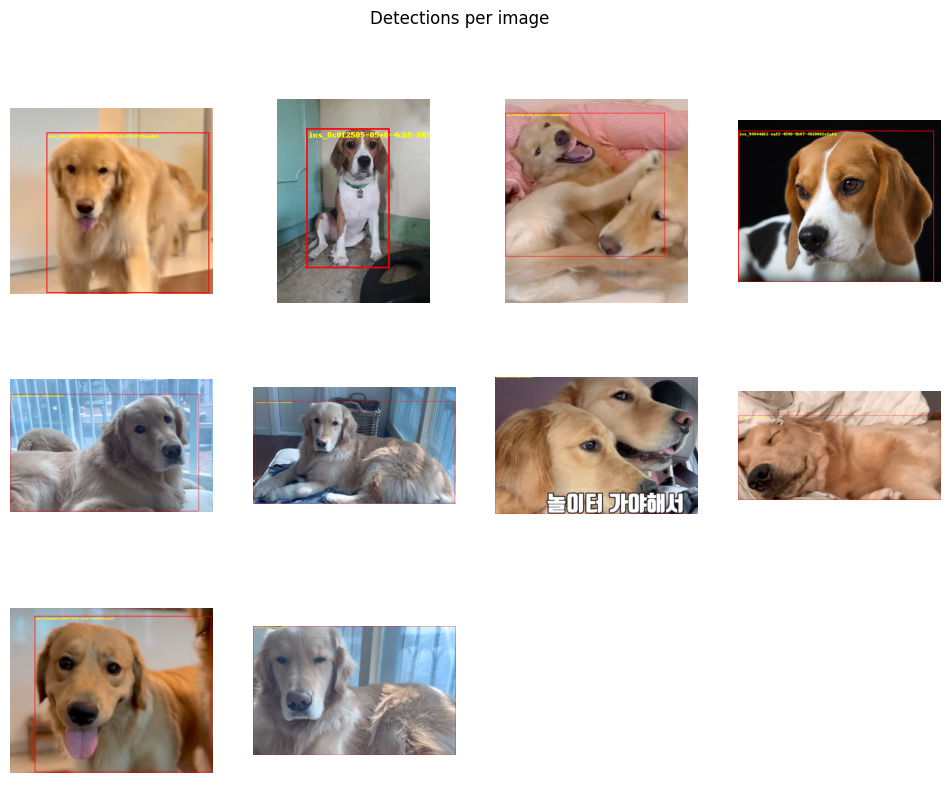

In [4]:
def ingest_many(paths, max_items=10):
    results = []
    for p in paths:
        if not is_valid_image(p):
            continue
        try:
            resp = ingest_image(str(p), include_embedding=False)
            results.append((p, resp))
        except Exception as e:
            print('ingest failed:', p, e)
        if len(results) >= max_items:
            break
    return results

ingest_results = ingest_many(sample_paths, max_items=10)
print('ingested:', len(ingest_results))

vis_imgs = []
for p, resp in ingest_results:
    img = load_image(str(p))
    instances = resp.get('instances', [])
    vis = draw_boxes(img, instances)
    vis_imgs.append(vis)

show_grid(vis_imgs, cols=4, title='Detections per image')


## Scenario C: Search using instances from multiple images
Pick instance_ids from the ingested responses and run a search.


In [5]:
instance_ids = []
for _p, resp in ingest_results:
    inst = resp.get('instances') or []
    if inst:
        instance_ids.append(inst[0].get('instance_id'))

instance_ids = [i for i in instance_ids if i]
print('query instance_ids:', instance_ids)

if instance_ids:
    body = {
        'daycare_id': DAYCARE_ID,
        'query': {'instance_ids': instance_ids, 'merge': 'RRF'},
        'filters': {'species': 'DOG'},
        'top_k_images': 10,
        'per_query_limit': 50,
    }
    r = requests.post(f'{API_URL}/v1/search', json=body, timeout=60)
    r.raise_for_status()
    print(r.json())
else:
    print('No instance_ids to query')


query instance_ids: ['ins_85c38512-78f5-4af9-81c4-81bffffaadb0', 'ins_8c0f2505-05e6-4cb5-8692-50bb0dbca099', 'ins_510d026f-cb59-42c8-92c2-e98d4f33c229', 'ins_94944d61-eaff-4590-9b87-492806fefefd', 'ins_242a4d6e-5e8a-4d97-9788-6abbc544e55a', 'ins_4863917c-eff8-4ca5-92ae-0cad39ff6db4', 'ins_10b33a05-8744-423f-99b5-5253ce19044c', 'ins_57475b01-bca6-49b4-9515-e72b5e161ac0', 'ins_c68ae0fa-d1f8-432f-91a5-6425553ca147', 'ins_413d7066-e963-4352-b665-5eea2dcd7576']
{'query_debug': {'used_vectors': 10, 'merge': 'RRF', 'per_query_limit': 50, 'top_k_images': 10}, 'results': [{'image_id': 'img_5f3f2dfe50f54f95bc9df5c67c4e1265', 'score': 0.12396047380029071, 'best_match': {'instance_id': 'ins_47a4320c-c912-4a20-9b49-3387d298803e', 'bbox': {'x1': 0.005411720369011164, 'y1': 0.11996202170848846, 'x2': 0.941192388534546, 'y2': 0.989421546459198}, 'score': 0.98030317}}, {'image_id': 'img_05feb735ce714e5384709400114388af', 'score': 0.12080951546013692, 'best_match': {'instance_id': 'ins_850a87b0-15e8-47b